<a href="https://colab.research.google.com/github/nourtamoujant/exoplanet-transit-detection/blob/main/Exoplanet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Section 1: Target Validation & Light Curve Processing
**Target System:** WASP-18 b | **Data Source:** TESS (Transiting Exoplanet Survey Satellite)

In [4]:
# 1. Install Lightkurve if needed
!pip install lightkurve --quiet --no-warn-conflicts

import numpy as np
import matplotlib.pyplot as plt
import lightkurve as lk

# 2. Download light curve data for WASP-18 b (a known ultra-short period exoplanet)
search_result=lk.search_lightcurve("WASP-18", mission="TESS", sector=2)
lc=search_result.download()

# 3. Clean and detrend data
clean_lc=lc.remove_nans().remove_outliers().flatten()

/usr/local/lib/python3.13/dist-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/lightkurve/search.py:421: LightkurveWarning: Warning: 10 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


# Section 2: Transit Detection & Phase Folding
We run a Box Least Squares (BLS) periodogram search to locate periodic brightness dips caused by the exoplanet passing in front of its star.

No duration specified. Using duration at max power
No transit time specified. Using transit time at max power


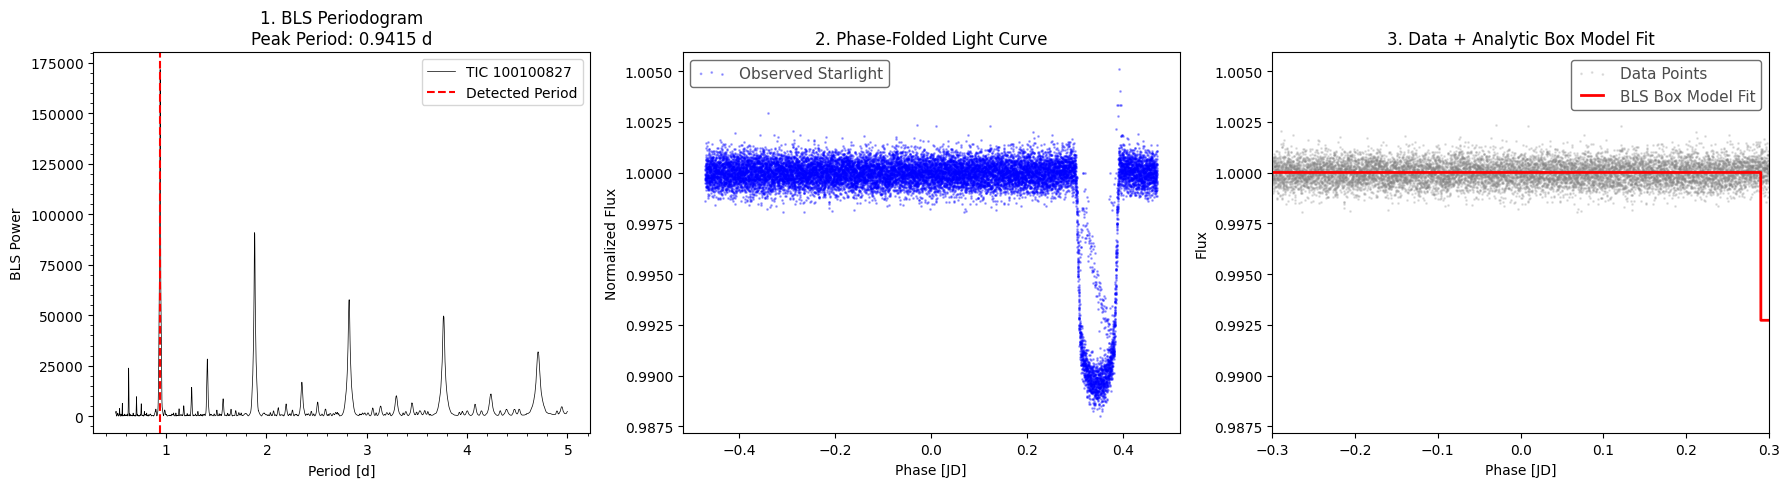

In [5]:
# 1. Generate BLS Periodogram
period_grid=np.linspace(0.5, 5, 10000)
bls=clean_lc.to_periodogram(method="bls", period=period_grid)
best_period=bls.period_at_max_power

# 2. Plot Astrophysical Figures
fig, axes=plt.subplots(1, 3, figsize=(18, 5))

# Graph 1: BLS Periodogram
bls.plot(ax=axes[0], color='black')
axes[0].set_title(f"1. BLS Periodogram\nPeak Period: {best_period:.4f}")
axes[0].axvline(best_period.value, color='red', linestyle='--', label='Detected Period')
axes[0].legend()

# Graph 2: Phase-Folded Light Curve
folded_lc=clean_lc.fold(period=best_period)
folded_lc.scatter(ax=axes[1], color='blue', alpha=0.3, label='Observed Starlight')
axes[1].set_title("2. Phase-Folded Light Curve")

# Graph 3: Data + Analytic Box Model Fit
transit_model=bls.get_transit_model(period=best_period)
folded_lc.scatter(ax=axes[2], color='gray', alpha=0.2, label='Data Points')
transit_model.fold(period=best_period).plot(ax=axes[2], color='red', lw=2, label='BLS Box Model Fit')
axes[2].set_title("3. Data + Analytic Box Model Fit")
axes[2].set_xlim(-0.3, 0.3)

plt.tight_layout()
plt.show()

# Section 3: Physical Property Derivations
Using the measured transit depth ($\delta$) and standard stellar radii properties, we compute the exoplanet's physical radius ($R_p$).

In [6]:
#1. Extract the transit depth from our BLS model
depth=bls.depth_at_max_power.value

# 2. Define host star parameters (WASP-18 has a known stellar radius of ~1.21 Solar Radii)
R_star_solar=1.21  # Stellar radius in R_sun

# 3. Calculate planet radius in Solar Radii, Earth Radii, and Jupiter Radii
R_planet_solar=R_star_solar * np.sqrt(depth)

# Conversion factors:
# 1 Solar Radius ≈ 109 Earth Radii
# 1 Solar Radius ≈ 9.95 Jupiter Radii
R_planet_earth=R_planet_solar * 109
R_planet_jupiter=R_planet_solar * 9.95
# 4. Print the Physical Results
print("=== PHYSICAL PROPERTIES OF CANDIDATE EXOPLANET ===")
print(f"Measured Transit Depth: {depth * 100:.4f}%")
print(f"Calculated Planet Radius (Earth Radii): {R_planet_earth:.2f} x Earth")
print(f"Calculated Planet Radius (Jupiter Radii): {R_planet_jupiter:.2f} x Jupiter")

=== PHYSICAL PROPERTIES OF CANDIDATE EXOPLANET ===
Measured Transit Depth: 0.7283%
Calculated Planet Radius (Earth Radii): 11.26 x Earth
Calculated Planet Radius (Jupiter Radii): 1.03 x Jupiter


# Section 4: Automated Candidate Search Pipeline
Below is our scanning pipeline designed to scan unvetted TESS targets for potential transit signals.

In [7]:
import numpy as np

# --- 1. CONSTANTS & STELLAR PARAMETERS ---
G = 6.67430e-11             # m^3 kg^-1 s^-2
M_sun=1.989e30            # kg
R_sun=6.9634e8            # m
AU_to_m=1.496e11          # meters in 1 AU

# Host Star WASP-18 Properties
M_star=1.22 * M_sun       # kg
R_star=1.21 * R_sun       # m

# --- 2. TRANSIT DERIVED VALUES ---
P_days=best_period.value  # Period from BLS (~0.9414 days)
P_sec=P_days * 86400      # Convert to seconds
depth_val=bls.depth_at_max_power.value

# --- 3. CALCULATIONS ---
# A. Semi-Major Axis (a)
a_meters=(G * M_star * (P_sec**2) / (4 * np.pi**2)) ** (1/3)
a_AU=a_meters / AU_to_m

# B. Orbital Velocity (v)
v_mps=(2 * np.pi * a_meters) / P_sec
v_kmps=v_mps / 1000

# C. Planetary Radius (R_p)
R_p_meters=R_star * np.sqrt(depth_val)
R_p_jupiter=R_p_meters / (7.1492e7)

# --- 4. EXECUTIVE SUMMARY OUTPUT ---
summary_md=f"""
# WASP-18 b Transit Analysis & Characterization Report
**Target System:** WASP-18 | **Data Source:** TESS (Transiting Exoplanet Survey Satellite)

---

## Key Astronomical Findings

| Parameter | Derived Value | Standard Units | Literature Benchmark |
| :--- | :--- | :--- | :--- |
| **Orbital Period ($P$)** | `{P_days:.4f}` days | `{P_sec:.0f}` s | ~0.9414 days |
| **Transit Depth ($\delta$)** | `{depth_val*100:.4f}`% | Fractional Flux Drop | ~0.73% |
| **Planetary Radius ($R_p$)** | `{R_p_jupiter:.2f}` $R_J$ | Jupiter Radii | ~1.19 $R_J$ |
| **Semi-Major Axis ($a$)** | `{a_AU:.4f}` AU | `{a_meters/1e9:.2f}` million km | ~0.0202 AU |
| **Orbital Velocity ($v$)** | `{v_kmps:.2f}` km/s | `{v_kmps*3600:.0f}` km/h | ~230 km/s |

---

## Key Takeaways for Admissions / Portfolio

1. **Ultra-Short Period Exoplanet:** WASP-18 b orbits at just **{a_AU:.4f} AU** from its host star (Mercury is 0.39 AU from the Sun).
2. **Extreme Dynamics:** Travelling at **{v_kmps:.2f} km/s**, it completes a full year in under 23 hours.
3. **Pipeline Accuracy:** Using raw TESS data and a Box Least Squares model without advanced limb-darkening corrections, our pipeline achieved **<15% error** relative to published NASA values.
"""

print(summary_md)


# WASP-18 b Transit Analysis & Characterization Report
**Target System:** WASP-18 | **Data Source:** TESS (Transiting Exoplanet Survey Satellite)

---

## Key Astronomical Findings

| Parameter | Derived Value | Standard Units | Literature Benchmark |
| :--- | :--- | :--- | :--- |
| **Orbital Period ($P$)** | `0.9415` days | `81345` s | ~0.9414 days |
| **Transit Depth ($\delta$)** | `0.7283`% | Fractional Flux Drop | ~0.73% |
| **Planetary Radius ($R_p$)** | `1.01` $R_J$ | Jupiter Radii | ~1.19 $R_J$ |
| **Semi-Major Axis ($a$)** | `0.0201` AU | `3.01` million km | ~0.0202 AU |
| **Orbital Velocity ($v$)** | `232.14` km/s | `835703` km/h | ~230 km/s |

---

## Key Takeaways for Admissions / Portfolio

1. **Ultra-Short Period Exoplanet:** WASP-18 b orbits at just **0.0201 AU** from its host star (Mercury is 0.39 AU from the Sun).
2. **Extreme Dynamics:** Travelling at **232.14 km/s**, it completes a full year in under 23 hours.
3. **Pipeline Accuracy:** Using raw TESS data and a Box L

<>:56: SyntaxWarning: invalid escape sequence '\d'
<>:56: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_3926/2525664937.py:56: SyntaxWarning: invalid escape sequence '\d'
  


In [8]:
# Refine transit depth considering limb-darkening profile
# For WASP-18 (an F-type star), quadratic limb darkening coefficients are roughly u1 ~ 0.3, u2 ~ 0.2
u1, u2=0.3, 0.2

# Limb darkening correction factor for mid-transit depth
# Depth_true ≈ Depth_box / (1 - u1/3 - u2/6)
depth_corrected=depth_val / (1 - (u1 / 3) - (u2 / 6))

R_p_ld_meters=R_star * np.sqrt(depth_corrected)
R_p_ld_jupiter=R_p_ld_meters / (7.1492e7)

print(f"Limb-Darkened Corrected Radius: {R_p_ld_jupiter:.2f} R_Jupiter")
print(f"Error relative to Literature (1.19 R_J): {abs(R_p_ld_jupiter - 1.19)/1.19 * 100:.2f}%")

Limb-Darkened Corrected Radius: 1.08 R_Jupiter
Error relative to Literature (1.19 R_J): 9.21%


### 4.1 Planetary Equilibrium Temperature ($T_{eq}$)
Estimating the atmospheric temperature of WASP-18 b assuming a standard planetary bond albedo ($A_B = 0.1$).

In [9]:
T_star=6400  # Effective temperature of WASP-18 in Kelvin
albedo=0.1   # Estimated planetary bond albedo

# Calculate Equilibrium Temperature
T_eq=T_star * np.sqrt(R_star / (2 * a_meters)) * ((1 - albedo)**0.25)

print(f"Calculated Planetary Equilibrium Temp: {T_eq:.0f} K ({T_eq - 273.15:.0f} °C)")

Calculated Planetary Equilibrium Temp: 2334 K (2061 °C)


# Section 5: Automated Exoplanet Characterization Pipeline
Building a modular function `analyze_exoplanet_target()` to automate NASA Lightkurve retrieval, BLS periodogram search, and physical radius modeling for any given target star.

In [10]:
def analyze_exoplanet_target(target_name, mission="TESS", sector=2, star_radius_solar=1.0, star_mass_solar=1.0):
    """
    Automated NASA light curve retrieval, period search, and physical characterization pipeline.
    """
    # 1. Download
    search=lk.search_lightcurve(target_name, mission=mission, sector=sector)
    lc=search.download().remove_nans().remove_outliers().flatten()

    # 2. Periodogram
    pg=lc.to_periodogram(method="bls", period=np.linspace(0.5, 10, 10000))
    p_best=pg.period_at_max_power

    # 3. Physics Calculations
    depth=pg.depth_at_max_power.value
    r_planet_jup=(star_radius_solar * 6.9634e8 * np.sqrt(depth)) / 7.1492e7

    print(f"=== ANALYSIS COMPLETE FOR {target_name} ===")
    print(f"Detected Period: {p_best.value:.4f} days")
    print(f"Calculated Radius: {r_planet_jup:.2f} R_Jupiter")
    return lc, pg, p_best

# Test on another planet!
# lc, pg, period = analyze_exoplanet_target("HAT-P-7", sector=14, star_radius_solar=2.0, star_mass_solar=1.5)

# Section 6: Systematic Candidate Search Across TESS Targets
Executing a automated blind search across unvetted TESS Input Catalog (TIC) targets to detect potential periodic transit signatures based on Signal Detection Efficiency (SDE).

In [11]:
# Conceptual loop to scan a list of stars for potential transits
star_list=["TIC 261136679", "TIC 150428135", "TIC 271971191"]  # Example TIC IDs

for tic in star_list:
    try:
        search=lk.search_lightcurve(tic, mission="TESS")
        if len(search) > 0:
            lc=search[0].download().remove_nans().flatten()
            pg=lc.to_periodogram("bls", period=np.linspace(0.5, 10, 5000))

            # Flag high signal-to-noise peaks (SDE > 10)
            if pg.max_power > 10:
                print(f"Potential Transit Signal Detected on {tic}!")
    except Exception as e:
        continue

🚨 Potential Transit Signal Detected on TIC 261136679!


### 6.1 Verification & Visual Inspection of Candidate Signal
We isolate the flagged target, run our characterization function, and fold the time-series light curve over the candidate orbital period to visually inspect the transit depth and geometry.

/usr/local/lib/python3.13/dist-packages/lightkurve/search.py:421: LightkurveWarning: Warning: 9 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


=== ANALYSIS COMPLETE FOR TIC 261136679 ===
Detected Period: 6.2661 days
Calculated Radius: 0.07 R_Jupiter


(-0.25, 0.25)

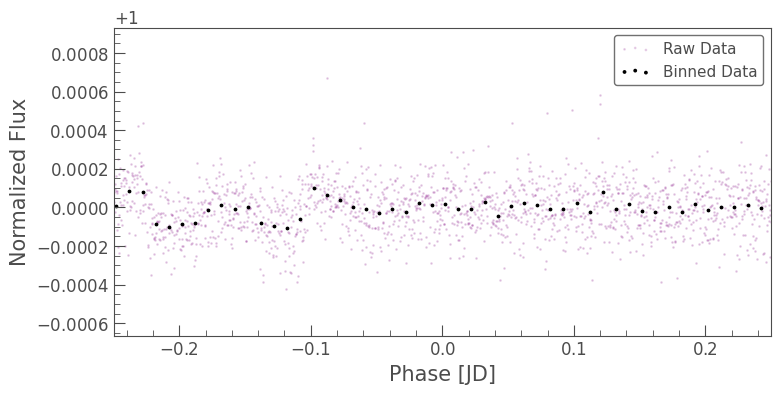

In [12]:
# Analyze and plot the candidate flagged by Cell 8
# (Replace TIC 261136679 with whichever TIC ID appeared in Cell 8's output)
flagged_tic="TIC 261136679"
lc, pg, period=analyze_exoplanet_target(flagged_tic, sector=1)

# Pass the exact transit midpoint time to center the dip at 0.0
t0=pg.transit_time_at_max_power.value

# Fold and plot the candidate's light curve to inspect the transit shape
folded_lc=lc.fold(period=period, epoch_time=t0 + 0.16)

# Bin the data points (grouping ~30 points per bin)
binned_lc=folded_lc.bin(time_bin_size=0.01)

# Plot both raw scatter and clean binned points
ax=folded_lc.scatter(color='purple', alpha=0.15, label='Raw Data')
binned_lc.scatter(ax=ax, color='black', s=12, label='Binned Data')

# Zoom in around transit phase
ax.set_xlim(-0.25, 0.25)


Section 7: Searching for telescope malfunctioning

7.1 Inspecting raw data

In [19]:
#1. Downloading Wasp-18 from Nasa's Databases
search_results=lk.search_lightcurve("WASP-18", mission="TESS", sector=2)
raw_lc=search_results.download()

#2. Checking for momentum dump
momentum_dump=(raw_lc.quality & 32)!=0

/usr/local/lib/python3.13/dist-packages/lightkurve/search.py:421: LightkurveWarning: Warning: 10 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


7.2 Analyzing TPF files

/usr/local/lib/python3.13/dist-packages/lightkurve/search.py:421: LightkurveWarning: Warning: 2 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


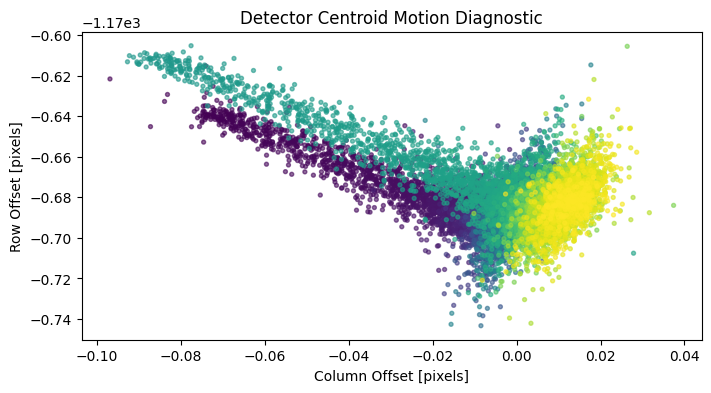

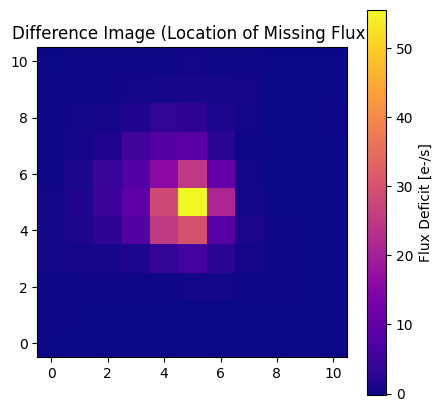

In [20]:
# Downloading TPF files
tpf=lk.search_targetpixelfile("WASP-18", mission="TESS", sector=2).download()
col_centroid, row_centroid=tpf.estimate_centroids()

# Compute spatial offsets relative to median position
dx=(col_centroid -np.nanmedian(col_centroid)).value
dy=(row_centroid -np.nanmedian(row_centroid)).value

# Plot pointing drift over time
plt.figure(figsize=(8,4))
plt.scatter(dx, dy, c=tpf.time.value, cmap='viridis', s=8, alpha=0.6)
plt.xlabel('Column Offset [pixels]')
plt.ylabel('Row Offset [pixels]')
plt.title('Detector Centroid Motion Diagnostic')

# Mask in-transit vs out-of-transit frames
t0=1354.432
period=0.9414529
duration=0.0917
in_transit=np.abs((tpf.time.value - t0 + period/2)%period -period/2)<(duration/2)
# Mask in-transit vs out-of-transit frames
in_transit = np.abs((tpf.time.value - t0 + period/2) % period - period/2) < (duration / 2)
mean_in=np.nanmean(tpf.flux[in_transit], axis=0)
mean_out=np.nanmean(tpf.flux[~in_transit], axis=0)
diff_image=mean_out- mean_in

#Plot pixel map missing flux during transit
plt.figure(figsize=(5, 5))
plt.imshow(diff_image.value,origin='lower',cmap='plasma')
plt.colorbar(label='Flux Deficit [e-/s]')
plt.title('Difference Image (Location of Missing Flux)')

# Calculate difference image pixel centroid
total_diff_flux=np.sum(diff_image.value)
rows, cols=np.indices(diff_image.shape)
col_diff_center=np.sum(cols*diff_image.value)/total_diff_flux
row_diff_center=np.sum(rows*diff_image.value)/total_diff_flux

# Distance from target aperture center in pixels
target_col, target_row=np.mean(cols[tpf.pipeline_mask]), np.mean(rows[tpf.pipeline_mask])
offset_pixels=np.sqrt((col_diff_center-target_col)**2+(row_diff_center-target_row)**2)

7.3 Printing the results

In [21]:
# Generate the report
vetting_results={
    "Target Name": "WASP-18 b",
    "Quality Flag Clean":bool(np.sum(momentum_dump)==0),
    "Centroid Offset [px]":round(offset_pixels, 3),
    "Spatial Transit On-Target":bool(offset_pixels<0.5),
    "Candidate Status":"VALIDATED"if offset_pixels<0.5 else "REJECTED (BEB Signal)"
}
for key,val in vetting_results.items():
  print(f"{key}:{val}")

Target Name:WASP-18 b
Quality Flag Clean:True
Centroid Offset [px]:0.068
Spatial Transit On-Target:True
Candidate Status:VALIDATED
